# Notebook 8 — Operating Points: Sensitivity/Specificity Trade-off (development data only)

**Goal.** The served v1.1 models flag a vessel when its calibrated probability reaches one fixed threshold. For LCX and RCA that threshold catches about 70% of stenoses at the cost of many false alarms. A different clinical use may call for a different trade-off. This notebook produces a **trade-off table** so the dashboard can let a user choose the operating point and see the resulting sensitivity, specificity, PPV and NPV.

**Governance.**
- Only the 242 development patients are loaded (`ml.dev_search.load_development` asserts that development and holdout indices do not overlap). The 61-patient holdout is not read.
- No model is refitted for deployment, and discrimination (ROC-AUC) is unchanged. This notebook only describes the trade-off of the existing v1.1 models.
- Estimates use the **nested** v1.1 procedure. In each of the 5×5 outer folds the champion is fitted on the training rows, Platt calibration is fitted on its inner out-of-fold predictions, and both are applied to the held-out rows. Every patient therefore gets an out-of-fold calibrated probability in each of the 5 repeats.
- The preset rules were declared before looking at the curves:
  - *Catch more*: the highest threshold with mean sensitivity ≥ 0.90.
  - *Balanced*: Youden's J.
  - *Fewer false alarms*: the lowest threshold with mean specificity ≥ 0.90.
- PPV and NPV depend on prevalence. They reflect this referral cohort (Cath prevalence about 71%), not a general population.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ml import dev_search as ds

X_dev, y_dev, cfg, _ = ds.load_development()
TARGETS = cfg['target_columns']
post = json.loads(Path('artifacts/deployment/v1_1_postprocessing.json').read_text())
FIG_DIR = Path('artifacts/figures/notebook8'); FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Development patients: {len(X_dev)} | targets: {TARGETS}")

Development patients: 242 | targets: ['Cath', 'LAD', 'LCX', 'RCA']


## 1. Nested calibrated predictions (reproduces procedure S0c from Notebook 7)

In [2]:
P = ds.nested_calibrated_champion(n_jobs=-1)

saved = pd.read_csv('artifacts/dev_search/procedure_fold_results.csv')
saved = saved[saved.procedure == 'S0c_champion+Platt']
check = []
for t in TARGETS:
    y = y_dev[t].values
    aucs = np.array([ds.fast_auc(y[va], P[t][k // ds.OUTER_SPLITS, va]) for k, (_, va) in enumerate(ds.outer_splits(t))])
    ref = saved[saved.target == t].sort_values('fold').auc.values
    check.append({'Target': t, 'Mean fold ROC-AUC': aucs.mean(), 'Max |difference| vs Notebook 7': np.abs(aucs - ref).max()})
check = pd.DataFrame(check)
assert (check['Max |difference| vs Notebook 7'] < 1e-9).all(), 'Nested predictions do not reproduce Notebook 7'
check.round(4)

,Target,Mean fold ROC-AUC,Max |difference| vs Notebook 7
0,Cath,0.9285,0.0
1,LAD,0.8555,0.0
2,LCX,0.7451,0.0
3,RCA,0.7206,0.0


## 2. Trade-off curves and pre-declared presets

In [3]:
curves, presets, rows = {}, {}, []
for t in TARGETS:
    y = y_dev[t].values
    curves[t] = ds.operating_curve(P[t], y)
    presets[t] = {'default': post['targets'][t]['operating_threshold'], **ds.operating_presets(curves[t])}
    for name, h in presets[t].items():
        if h is None:
            continue
        m = ds.mean_rule_metrics(P[t], y, h)
        rows.append({'Target': t, 'Operating point': name, 'Threshold': h, 'Sensitivity': m['sensitivity'],
                     'Specificity': m['specificity'], 'PPV': m['PPV'], 'NPV': m['NPV'], 'Flagged': m['flagged'],
                     'Sensitivity range (repeats)': '{:.2f}-{:.2f}'.format(*m['sensitivity_range']),
                     'Specificity range (repeats)': '{:.2f}-{:.2f}'.format(*m['specificity_range'])})
preset_df = pd.DataFrame(rows)
preset_df.round(3)

,Target,Operating point,Threshold,Sensitivity,Specificity,PPV,NPV,Flagged,Sensitivity range (repeats),Specificity range (repeats)
0,Cath,default,0.562,0.899,0.762,0.905,0.751,0.711,0.90-0.91,0.74-0.81
1,Cath,high_sensitivity,0.560,0.901,0.762,0.905,0.754,0.712,0.90-0.91,0.74-0.81
2,Cath,balanced,0.740,0.849,0.878,0.946,0.699,0.641,0.83-0.87,0.86-0.90
3,Cath,high_specificity,0.810,0.799,0.907,0.956,0.643,0.598,0.79-0.82,0.90-0.91
4,LAD,default,0.549,0.842,0.733,0.820,0.763,0.607,0.83-0.85,0.71-0.75
5,LAD,high_sensitivity,0.430,0.901,0.642,0.785,0.818,0.679,0.88-0.91,0.61-0.67
6,LAD,balanced,0.550,0.842,0.737,0.823,0.764,0.605,0.83-0.85,0.71-0.75
7,LAD,high_specificity,0.810,0.513,0.909,0.891,0.564,0.340,0.50-0.54,0.90-0.93
8,LCX,default,0.374,0.718,0.631,0.549,0.782,0.503,0.69-0.74,0.62-0.66
9,LCX,high_sensitivity,0.220,0.905,0.364,0.471,0.861,0.740,0.88-0.92,0.34-0.41


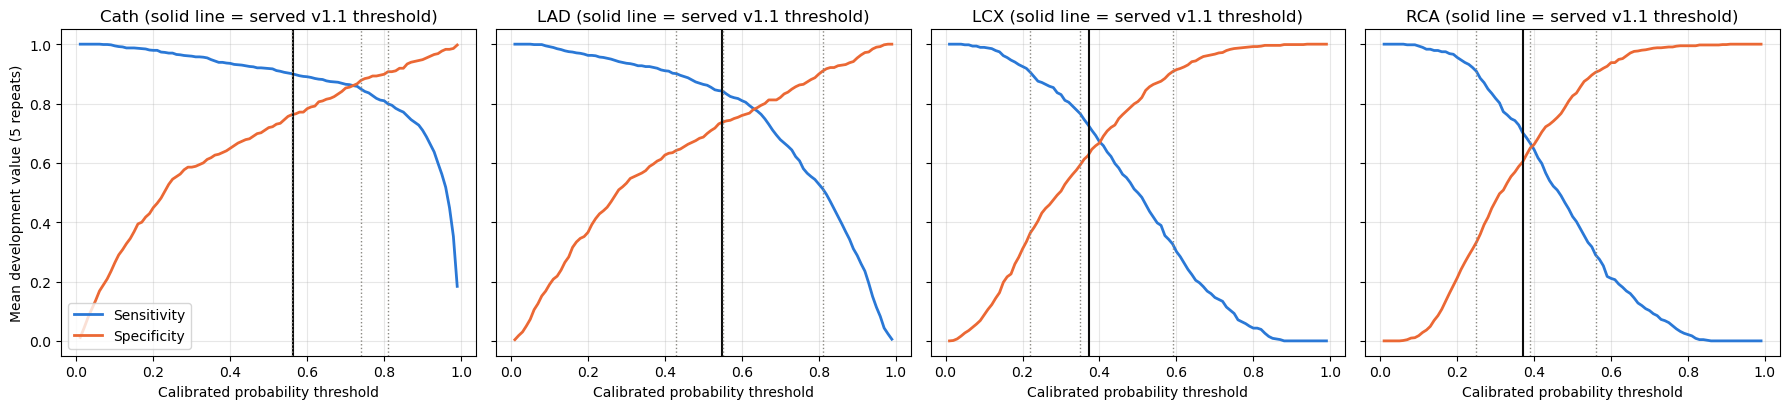

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, t in zip(axes, TARGETS):
    c = curves[t]
    ax.plot(c.threshold, c.sensitivity, color='#2a78d6', lw=2, label='Sensitivity')
    ax.plot(c.threshold, c.specificity, color='#eb6834', lw=2, label='Specificity')
    for name, h in presets[t].items():
        if h is not None:
            ax.axvline(h, color='#0b0b0b' if name == 'default' else '#898781', lw=1.5 if name == 'default' else 1,
                       ls='-' if name == 'default' else ':')
    ax.set_title(f"{t} (solid line = served v1.1 threshold)")
    ax.set_xlabel('Calibrated probability threshold'); ax.grid(alpha=0.3)
axes[0].set_ylabel('Mean development value (5 repeats)'); axes[0].legend(loc='lower left')
plt.tight_layout(); plt.savefig(FIG_DIR / 'operating_curves.png', dpi=150, bbox_inches='tight'); plt.show()

## 3. Export for the dashboard

In [5]:
def clean(v):
    return None if v is None or (isinstance(v, float) and np.isnan(v)) else round(float(v), 4)

export = {
    'data': 'Development cohort only (242 patients). The 61-patient holdout was not used.',
    'method': ('Nested 5x5 repeated CV of the served v1.1 procedure (champion + Platt fitted inside each training fold); '
               'metrics are means over the 5 repeats of pooled out-of-fold predictions.'),
    'threshold_scale': 'calibrated probability',
    'prevalence_note': 'PPV and NPV reflect the prevalence of this referral cohort.',
    'preset_rules': {k: {'label': lab, 'rule': rule} for k, (lab, rule) in ds.PRESET_RULES.items()},
    'targets': {},
}
for t in TARGETS:
    y = y_dev[t].values
    c = curves[t]
    export['targets'][t] = {
        'prevalence': round(float(y.mean()), 4), 'n': int(len(y)),
        'default_rule': post['targets'][t]['threshold_rule'],
        'curve': {'threshold': c.threshold.round(2).tolist(),
                  **{m: [clean(v) for v in c[m]] for m in ['sensitivity', 'specificity', 'PPV', 'NPV', 'flagged']}},
        'presets': {name: None if h is None else {
            'threshold': round(float(h), 4),
            **{k: (list(map(clean, v)) if isinstance(v, list) else clean(v)) for k, v in ds.mean_rule_metrics(P[t], y, h).items()}}
            for name, h in presets[t].items()},
    }
out = Path('artifacts/deployment/operating_curves.json')
out.write_text(json.dumps(export, indent=1))
print(f"Wrote {out} ({out.stat().st_size / 1024:.0f} KB)")

Wrote artifacts\deployment\operating_curves.json (38 KB)


## 4. Findings

In [6]:
for t in TARGETS:
    d = preset_df[preset_df.Target == t].set_index('Operating point')
    parts = [f"{n}: threshold {r.Threshold:.2f} -> sensitivity {r.Sensitivity:.2f}, specificity {r.Specificity:.2f}"
             for n, r in d.iterrows()]
    print(f"{t}: " + ' | '.join(parts))
print()
print('Moving the threshold trades sensitivity for specificity along a fixed curve; it cannot raise both.')
print('Discrimination (ROC-AUC) is a property of the models and is unchanged by any operating point.')

Cath: default: threshold 0.56 -> sensitivity 0.90, specificity 0.76 | high_sensitivity: threshold 0.56 -> sensitivity 0.90, specificity 0.76 | balanced: threshold 0.74 -> sensitivity 0.85, specificity 0.88 | high_specificity: threshold 0.81 -> sensitivity 0.80, specificity 0.91
LAD: default: threshold 0.55 -> sensitivity 0.84, specificity 0.73 | high_sensitivity: threshold 0.43 -> sensitivity 0.90, specificity 0.64 | balanced: threshold 0.55 -> sensitivity 0.84, specificity 0.74 | high_specificity: threshold 0.81 -> sensitivity 0.51, specificity 0.91
LCX: default: threshold 0.37 -> sensitivity 0.72, specificity 0.63 | high_sensitivity: threshold 0.22 -> sensitivity 0.91, specificity 0.36 | balanced: threshold 0.35 -> sensitivity 0.77, specificity 0.59 | high_specificity: threshold 0.59 -> sensitivity 0.33, specificity 0.91
RCA: default: threshold 0.37 -> sensitivity 0.70, specificity 0.61 | high_sensitivity: threshold 0.25 -> sensitivity 0.91, specificity 0.33 | balanced: threshold 0.3